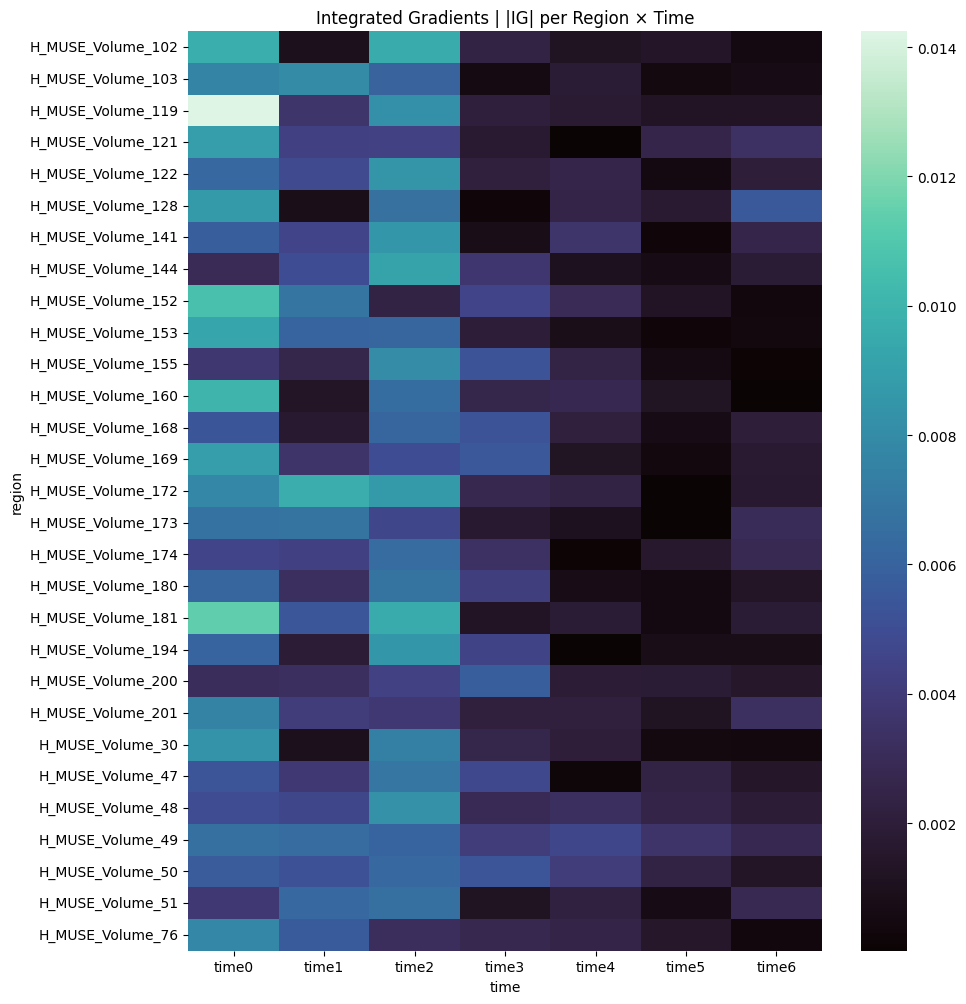

In [1]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

summary = pd.read_csv("tralzformer_september/model_predictions/Exp_08_09/Exp_08_09_ConversionPrediction_7V_fold_1_Preds_ig_summary.csv")
summary = summary[summary["region"] != "Age"]  
summary = summary[summary["region"] != "delta_t_months"]  
#summary = pd.read_csv("model_predictions/Modality_B_03_09_02_Old_Sol_fold_1_Preds_ig_summary.csv")
pivot = summary.pivot(index="region", columns="time", values="abs_mean").fillna(0)
plt.figure(figsize=(10, max(6, 0.35*len(pivot))))
sns.heatmap(pivot, cmap="mako", annot=False)
plt.title("Integrated Gradients | |IG| per Region × Time")
plt.tight_layout(); plt.show()

In [14]:
import numpy as np

def top_k_regions_per_time(
    summary_csv: str | pd.DataFrame,
    metric: str = "abs_mean",    # "abs_mean" (importance) or "mean" (directional)
    k: int = 10,
    min_count: int | None = None,
    time_col: str = "time",
    region_col: str = "region"
) -> pd.DataFrame:
    """
    Return the top-k regions per time step by `metric`.
    Expects columns: region, time, metric, (optional) count.
    """

    # --- Load ---
    df = pd.read_csv(summary_csv) if isinstance(summary_csv, str) else summary_csv.copy()

    df = df[df["region"] != "Age"]  
    df = df[df["region"] != "delta_t_months"]  

    # --- Sanity checks ---
    for col in [time_col, region_col, metric]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}'. Found: {list(df.columns)}")

    # --- Optional: filter by minimum sample count ---
    if min_count is not None and "count" in df.columns:
        df = df[df["count"] >= min_count].copy()

    # --- Coerce time to numeric (handles 'time0', 't6', etc.) ---
    if not np.issubdtype(df[time_col].dtype, np.number):
        extracted = pd.to_numeric(
            df[time_col].astype(str).str.extract(r"(\d+)")[0],
            errors="coerce"
        )
        # If extraction fails everywhere, keep original; else use numeric
        if extracted.notna().any():
            df[time_col] = extracted

    # --- Coerce metric to numeric & drop NaNs in metric ---
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric])

    if df.empty:
        raise ValueError("No rows left after filtering/coercion. Check `min_count` and column names/types.")

    # --- Sort and take top-k per time ---
    df_sorted = df.sort_values([time_col, metric], ascending=[True, False])
    topk = (df_sorted
            .groupby(time_col, group_keys=True, sort=True)
            .head(k)
            .copy())

    # --- Add rank within each time ---
    topk["rank"] = (topk.groupby(time_col)
                         .cumcount()
                         .add(1))

    # --- Nice column name for the metric ---
    topk = topk.rename(columns={metric: f"{metric}_score"})

    # --- Reorder columns ---
    keep_cols = [time_col, "rank", region_col, f"{metric}_score"]
    if "count" in topk.columns:
        keep_cols.append("count")
    # Keep any other columns too, but show the essentials first
    other_cols = [c for c in topk.columns if c not in keep_cols]
    topk = topk[keep_cols + other_cols].sort_values([time_col, "rank"]).reset_index(drop=True)

    return topk

# ---- usage ----
summary_path = "tralzformer_september/model_predictions/Exp_08_09_Cluster0/Exp_08_09_ConversionPrediction_7V_Cluster0_fold_5_Preds_ig_summary.csv"
#summary_path = "model_predictions/Modality_B_03_09_02_Old_Sol_fold_1_Preds_ig_summary.csv"
top10_abs = top_k_regions_per_time(summary_path, metric="abs_mean", k=10, min_count=30)
print(top10_abs.head(100))

# Save for your report
fold = 5
top10_abs.to_csv(f"tralzformer_september/model_predictions/top10_regions_per_time_abs_mean_fold{fold}.csv", index=False)

# If you want the *directional* (signed) winners instead of absolute importance:
top10_signed = top_k_regions_per_time(summary_path, metric="mean", k=10, min_count=30)
top10_signed.to_csv(f"tralzformer_september/model_predictions/top10_regions_per_time_signed_mean_fold{fold}.csv", index=False)

# (Optional) make a compact wide table listing just the region names per time & rank
def to_wide_names(topk_df: pd.DataFrame) -> pd.DataFrame:
    names = (topk_df
             .pivot_table(index="time", columns="rank", values="region", aggfunc="first")
             .rename(columns=lambda r: f"Top{r}"))
    return names.reset_index()

wide_abs = to_wide_names(top10_abs)
wide_abs.to_csv(f"tralzformer_september/model_predictions/top10_regions_names_per_time_abs_fold{fold}.csv", index=False)
print(wide_abs.head())

    time  rank             region  abs_mean_score  count      mean       std
0      0     1  H_MUSE_Volume_154        0.010091    117 -0.001981  0.012206
1      0     2  H_MUSE_Volume_167        0.009008    117 -0.000696  0.010845
2      0     3  H_MUSE_Volume_128        0.009000    117  0.000737  0.011130
3      0     4   H_MUSE_Volume_47        0.007934    117 -0.001407  0.010134
4      0     5  H_MUSE_Volume_181        0.007913    117 -0.000653  0.010969
..   ...   ...                ...             ...    ...       ...       ...
65     6     6  H_MUSE_Volume_181        0.002576    117 -0.001369  0.007661
66     6     7   H_MUSE_Volume_47        0.002521    117  0.000102  0.008170
67     6     8  H_MUSE_Volume_122        0.002415    117 -0.000056  0.007207
68     6     9  H_MUSE_Volume_172        0.002237    117  0.000123  0.007037
69     6    10   H_MUSE_Volume_49        0.002219    117 -0.000225  0.006403

[70 rows x 7 columns]
rank  time               Top1               Top2     

In [15]:
import pandas as pd
from pathlib import Path

# --- Point these to your per-fold CSVs (the ones you pasted) ---
# If each fold is saved separately, list them here in any order:
files = [
    "tralzformer_september/model_predictions/Exp_08_09_Cluster0/top10_regions_per_time_abs_mean_fold1.csv",
    "tralzformer_september/model_predictions/Exp_08_09_Cluster0/top10_regions_per_time_abs_mean_fold2.csv",
    "tralzformer_september/model_predictions/Exp_08_09_Cluster0/top10_regions_per_time_abs_mean_fold3.csv",
    "tralzformer_september/model_predictions/Exp_08_09_Cluster0/top10_regions_per_time_abs_mean_fold4.csv",
    "tralzformer_september/model_predictions/Exp_08_09_Cluster0/top10_regions_per_time_abs_mean_fold5.csv",
]

# Read & concat
df = pd.concat([pd.read_csv(p) for p in files], ignore_index=True)

# Optional: if you kept 'Age' in some summaries and want to exclude it from interpretability:
# df = df[df["region"] != "Age"]

# Aggregate across folds & time: mean abs_mean_score per region
agg = (
    df.groupby("region", as_index=False)
      .agg(
          abs_mean_overall=("abs_mean_score", "mean"),
          appearances=("abs_mean_score", "size")  # how many (fold,time,rank) entries contributed
      )
      .sort_values("appearances", ascending=False)
)

top10 = agg.head(10).reset_index(drop=True)

# Neat display
print(top10)

# Optional: LaTeX table you can paste into the thesis
latex = [
    r"\begin{table}[H]",
    r"\centering",
    r"\caption{Top 10 regions by mean $|$IG$|$ across folds and time}",
    r"\label{tab:ig_top10_overall}",
    r"\resizebox{0.7\textwidth}{!}{",
    r"\begin{tabular}{l c c}",
    r"\hline",
    r"\textbf{Region} & \textbf{Mean $|$IG$|$} & \textbf{Appearances} \\",
    r"\hline",
]

for _, row in top10.iterrows():
    latex.append(f"{row['region']} & {row['abs_mean_overall']:.4f} & {int(row['appearances'])} \\\\")
latex += [
    r"\hline",
    r"\end{tabular}",
    r"}",
    r"\end{table}",
]
print("\n".join(latex))

              region  abs_mean_overall  appearances
0   H_MUSE_Volume_49          0.004322           17
1  H_MUSE_Volume_167          0.006053           15
2  H_MUSE_Volume_173          0.005355           12
3  H_MUSE_Volume_121          0.005303           12
4   H_MUSE_Volume_48          0.004930           12
5  H_MUSE_Volume_181          0.006914           11
6  H_MUSE_Volume_141          0.004528           11
7  H_MUSE_Volume_122          0.004529           11
8   H_MUSE_Volume_50          0.004227           10
9  H_MUSE_Volume_119          0.005510           10
\begin{table}[H]
\centering
\caption{Top 10 regions by mean $|$IG$|$ across folds and time}
\label{tab:ig_top10_overall}
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{l c c}
\hline
\textbf{Region} & \textbf{Mean $|$IG$|$} & \textbf{Appearances} \\
\hline
H_MUSE_Volume_49 & 0.0043 & 17 \\
H_MUSE_Volume_167 & 0.0061 & 15 \\
H_MUSE_Volume_173 & 0.0054 & 12 \\
H_MUSE_Volume_121 & 0.0053 & 12 \\
H_MUSE_Volume_48 & 0.0049 & 12 \\
